Đang huấn luyện mô hình Binary...

--- KẾT QUẢ BINARY CLASSIFICATION ---
Accuracy: 0.8017973040439341

--- CHI TIẾT MA TRẬN NHẦM LẪN ---
True Positives (TP - Đoán đúng bị bệnh): 179
True Negatives (TN - Đoán đúng khỏe mạnh): 1427
False Positives (FP - Dương tính giả/Báo động nhầm): 167
False Negatives (FN - Âm tính giả/Bỏ lót bệnh): 230

Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.90      0.88      1594
         1.0       0.52      0.44      0.47       409

    accuracy                           0.80      2003
   macro avg       0.69      0.67      0.68      2003
weighted avg       0.79      0.80      0.80      2003



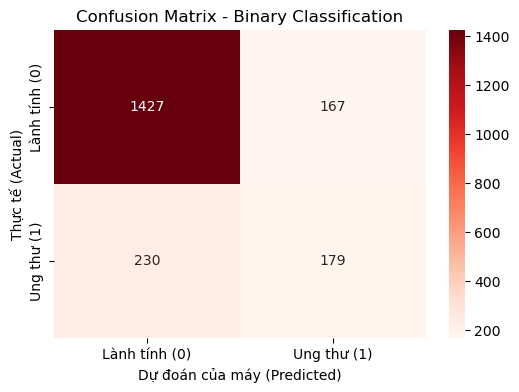

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import pandas as pd

data = pd.read_csv(os.path.join('data', 'processed_data.csv'))
X_bin = data[['age', 'sex', 'localization', 'dx_type']]
y_bin = data['y_binary']

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42
)


svm_binary = SVC(kernel='rbf', probability=True, random_state=42)
svm_binary.fit(X_train_bin, y_train_bin)

y_pred_bin = svm_binary.predict(X_test_bin)
print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin))

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
tn, fp, fn, tp = cm_bin.ravel()


print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print("\nReport:\n", classification_report(y_test_bin, y_pred_bin))

# 5. Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Lành tính (0)', 'Ung thư (1)'], 
            yticklabels=['Lành tính (0)', 'Ung thư (1)'])
plt.title('Confusion Matrix - Binary Classification')
plt.xlabel('Dự đoán của máy (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

# Lưu model
with open(os.path.join('models', 'svm_binary.pkl'), 'wb') as f:
    pickle.dump(svm_binary, f)

Đang huấn luyện mô hình Multi-class...

--- KẾT QUẢ MULTI-CLASS CLASSIFICATION ---
Accuracy: 0.6919620569146281

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        69
           1       0.00      0.00      0.00        93
           2       0.43      0.25      0.31       228
           3       0.00      0.00      0.00        28
           4       0.77      0.96      0.85      1338
           5       0.24      0.21      0.23       226
           6       0.00      0.00      0.00        21

    accuracy                           0.69      2003
   macro avg       0.20      0.20      0.20      2003
weighted avg       0.59      0.69      0.63      2003



c:\Users\nguye\anaconda3\envs\skincancer_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nguye\anaconda3\envs\skincancer_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nguye\anaconda3\envs\skincancer_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

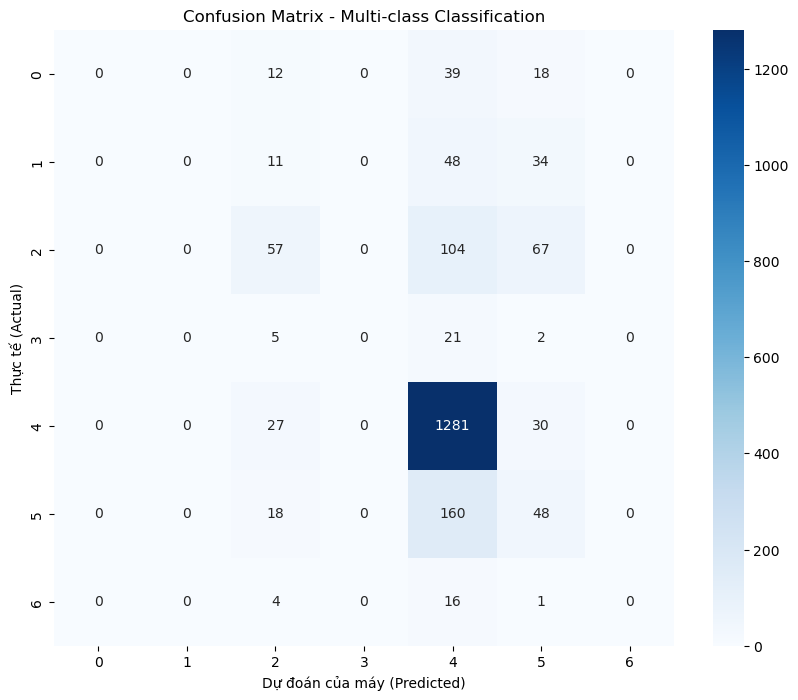

In [ ]:
X_mul = data[['age', 'sex', 'localization', 'dx_type']]
y_mul = data['y_multi']

X_train_mul, X_test_mul, y_train_mul, y_test_mul = train_test_split(
    X_mul, y_mul, test_size=0.2, random_state=42
)

svm_multi = SVC(kernel='rbf', probability=True, random_state=42)
svm_multi.fit(X_train_mul, y_train_mul)

y_pred_mul = svm_multi.predict(X_test_mul)
print("Accuracy:", accuracy_score(y_test_mul, y_pred_mul))
print("\nClassification Report:\n", classification_report(y_test_mul, y_pred_mul))


cm_multi = confusion_matrix(y_test_mul, y_pred_mul)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Multi-class Classification')
plt.xlabel('Dự đoán của máy (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

# Lưu model
with open(os.path.join('models', 'svm_multi.pkl'), 'wb') as f:
    pickle.dump(svm_multi, f)